In [4]:
import numpy as numpy
import pandas 
import matplotlib.pyplot as matplot
import seaborn
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split # pacote pra testar o modelo

In [5]:
data = pandas.read_csv('dataset.csv')

In [6]:
data.shape   #linhas e colunas 

(500, 2)

In [7]:
data.columns

Index(['horas_estudo_mes', 'salario'], dtype='object')

In [8]:
data.head()

,horas_estudo_mes,salario
0,57.0,6813.0
1,48.0,6855.0
2,60.0,5801.0
3,73.0,7431.0
4,46.0,5475.0


In [9]:
data.info() #verificar se nao tem nenhun valor ausente 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   horas_estudo_mes  500 non-null    float64
 1   salario           500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [10]:
data.isnull().sum() # mais uma checagem extra 

horas_estudo_mes    0
salario             0
dtype: int64

In [11]:
data.corr()  # correlacao entre os dados na diagonal

,horas_estudo_mes,salario
horas_estudo_mes,1.000000,0.818576
salario,0.818576,1.000000


In [12]:
data.describe()

,horas_estudo_mes,salario
count,500.000000,500.000000
mean,50.060000,6018.930000
std,14.659406,848.697853
min,1.000000,3664.000000
25%,39.750000,5473.000000
50%,50.000000,6013.500000
75%,60.000000,6542.000000
max,100.000000,9348.000000


In [13]:
data['horas_estudo_mes'].describe() # descricao somente da variavel preditora.

count    500.000000
mean      50.060000
std       14.659406
min        1.000000
25%       39.750000
50%       50.000000
75%       60.000000
max      100.000000
Name: horas_estudo_mes, dtype: float64

<Axes: xlabel='horas_estudo_mes', ylabel='Count'>

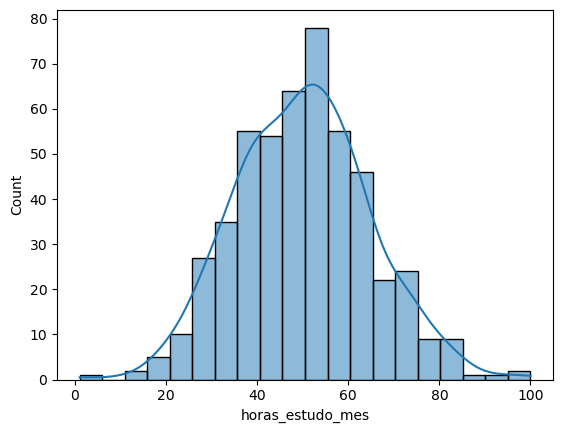

In [14]:
seaborn.histplot(data = data, x = 'horas_estudo_mes',kde = True)

In [16]:
x = numpy.array(data['horas_estudo_mes'])
# dados de entrada precisam ficar em uma matriz numpy

In [19]:
x = x.reshape(-1,1)
#formato para o sickit learn reconhecer

In [20]:
y = data['salario']

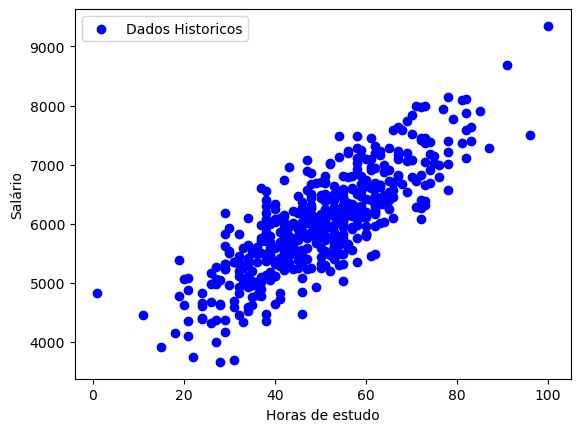

In [21]:
matplot.scatter(x,y, color = "blue", label = "Dados Historicos")
matplot.xlabel("Horas de estudo")
matplot.ylabel("Salário")
matplot.legend()
matplot.show()

In [22]:
#Divisao dos dados em treino e teste 
#precisamos usar amostras diferentes para saber se realmente o modelo aprendeu 

x_treino,x_teste,y_treino,y_teste = train_test_split(x,y,test_size = 0.2, random_state = 42)
# 20 por cento pra dado de teste e 80 para treino 
# random state faz uma divisao aleatoria 

In [23]:
x_treino.shape

(400, 1)

In [24]:
x_teste.shape

(100, 1)

## Modelagem preditiva(Machile learning)

In [25]:
modelo = LinearRegression()

In [26]:
modelo.fit(x_treino,y_treino)

LinearRegression()

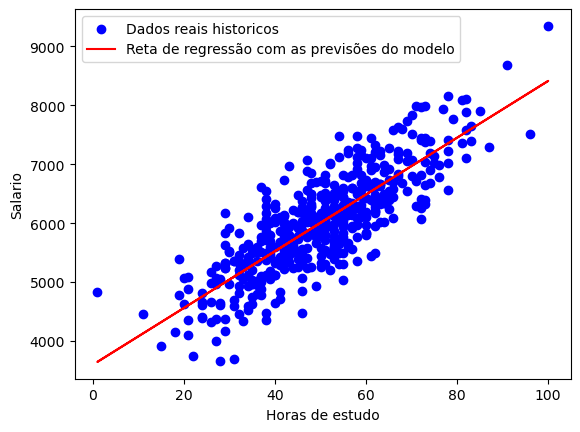

In [27]:
#Regressao linear é a previsao e os dados reais 
matplot.scatter(x,y, color ="blue" , label = "Dados reais historicos")
matplot.plot(x,modelo.predict(x),color = 'red', label = "Reta de regressão com as previsões do modelo")
matplot.xlabel("Horas de estudo")
matplot.ylabel("Salario")
matplot.legend()
matplot.show()

In [29]:
#avalia o modelo nos dados de teste 
score = modelo.score(x_teste,y_teste)
print(f"Coeficiente R^2: {score:.2f}")
#Quanto mais proximo de 1 o coeficiente, melhor 

Coeficiente R^2: 0.59


In [30]:
modelo.intercept_ # 

3596.783724372753

In [31]:
modelo.coef_

array([48.18185277])

## Deploy do modelo 